# Visualising Terrascope data with TiTiler and JupyterGIS

In this notebook we combine two complementary tools to explore Terrascope data interactively from within JupyterLab: [JupyterGIS](https://jupytergis.readthedocs.io) for visualisation, and [TiTiler](https://developmentseed.org/titiler/) for serving the underlying imagery.

**JupyterGIS** is a JupyterLab extension that brings an interactive GIS environment directly into your notebook. It lets you visualise raster and vector layers on an interactive map, stack and reorder them, adjust their opacity from the layer panel, and load data from a wide range of formats such as **GeoJSON, GeoTIFF, Shapefile, GeoPackage, WMS/WMTS** and more. You can even add markers and story segments to tell interactive stories.

To feed JupyterGIS with Terrascope imagery, we rely on **TiTiler**, a modern map tile server that makes it easy to serve geospatial data on the web. Think of it as a specialised tool that takes large geographic files (like satellite imagery) and slices them into small, web-friendly map tiles that load efficiently in browser-based maps — exactly the kind of layers JupyterGIS can consume.

Throughout the notebook we use JupyterGIS as our interactive viewer to explore what the Terrascope TiTiler service has to offer, drawing the map through its **Python API**:

1. Introduction to the Terrascope TiTiler
2. Finding available datasets in TiTiler
3. TiTiler COG endpoint
3. Rendering WMTS layers from TiTiler in JupyterGIS
5. More JupyterGIS features
6. Closing remarks


## 1. Introduction to the Terrascope TiTiler

[TiTiler](https://developmentseed.org/titiler/) is an open-source, FastAPI-based dynamic tile server for geospatial data. Instead of pre-generating tiles for every dataset, it reads Cloud Optimized GeoTIFFs (COGs) and STAC items on the fly and streams out map tiles, previews and statistics on demand.

The Terrascope TiTiler deployment at [titiler.terrascope.be](https://titiler.terrascope.be) exposes several standards-based endpoints on top of our data:

- **COG endpoint**: direct access to any Cloud Optimized GeoTIFF by URL.
- **OGC WMS**: Serves georeferenced map images (e.g., PNG/JPEG) generated dynamically from spatial data.
- **OGC WMTS**: Serves pre-rendered, tiled map images for faster and more scalable map viewing.

It is tightly integrated with the [Terrascope STAC API](https://stac.terrascope.be): TiTiler reads the asset file paths it needs for rendering, together with the product metadata (such as band information, nodata values and spatial extent), directly from STAC. This means you can point it at STAC collections and items and immediately get back web-ready tiles, without having to move or reprocess the underlying data.

The full interactive API specification is available at [titiler.terrascope.be/api.html](https://titiler.terrascope.be/api.html#/).

Lets define the base URL to the titiler service and its endpoints:


In [1]:
from yarl import URL
titiler_endpoint = URL("https://titiler.terrascope.be")
cog_endpoint = titiler_endpoint / "cog"
wms_endpoint = titiler_endpoint / "wms"
wmts_endpoint = titiler_endpoint / "wmts"

The health endpoint can be used to check if the TiTiler service is up and running, as well to check if the underlying STAC is working.

In [2]:
import requests
health_endpoint = titiler_endpoint / "healthz"
response = requests.get(str(health_endpoint))
if not response.ok:
    print(f"TiTiler service is not healthy: {response.status_code}")
else:
    print("Health check successful.")

Health check successful.


## 2. Discovering renderable datasets on Terrascope

[Terrascope](https://terrascope.be) exposes its Earth Observation archive through a [STAC](https://stacspec.org) (SpatioTemporal Asset Catalog) API. Each **collection** describes the metadata of a dataset. As we said in the last section, the TiTiler service uses the Terrascope STAC collections to retrieve information for visualisations. Some of these collections support the [STAC Renders extension](https://github.com/stac-extensions/render), which contain the information needed by TiTiler to render the items of the collection.

If you want to explore the collections that you can have two options on how to find them:
1. Search the STAC API directly and finding the collections that support the Renders extension.
2. Use the Terrascope TiTiler GetCapabilities endpoint, which returns a list of all collections that support rendering as an XML.

Lets retrieve the renderable collections using GetCapabilities endpoint of the TiTiler WMTS service.

In [3]:
import xml.etree.ElementTree as ET

get_capabilities_endpoint = wmts_endpoint.with_query(service="WMTS", request="GetCapabilities")
print("Used endpoint:", get_capabilities_endpoint)
response = requests.get(str(get_capabilities_endpoint))
if response.ok:
    root = ET.fromstring(response.text)
    ns = {
        "wmts": "http://www.opengis.net/wmts/1.0",
        "ows": "http://www.opengis.net/ows/1.1",
    }
    layers = root.findall(".//wmts:Contents/wmts:Layer", ns)
    print(f"Found {len(layers)} renderable layers:\n")
    for layer in layers:
        identifier = layer.findtext("ows:Identifier", default="", namespaces=ns)
        title = layer.findtext("ows:Title", default="", namespaces=ns)
        print(f"- {title or identifier}")
    print("...")
else:
    print(f"Failed to retrieve capabilities: {response.status_code}")

Used endpoint: https://titiler.terrascope.be/wmts?service=WMTS&request=GetCapabilities
Found 117 renderable layers:

- aria-s1-gunw-v1_unfiltered_coherence
- cop-dem-glo-90m-cog_dem
- cropsar2d-fapar-archive_fapar
- cropsar2d-fapar-nrt_fapar
- esa-worldcereal-activecropland-10m-2021-v1_classification
- esa-worldcereal-irrigation-10m-2021-v1_classification
- esa-worldcereal-maize-10m-2021-v1_classification
- esa-worldcereal-springcereals-10m-2021-v1_classification
- esa-worldcereal-temporarycrops-10m-2021-v1_classification
- esa-worldcereal-wintercereals-10m-2021-v1_classification
- esa-worldcover-map-10m-2020-v1_map
- esa-worldcover-map-10m-2021-v2_map
- esa-worldcover-ndvi-10m-2020-v1_ndvi
- esa-worldcover-ndvi-10m-2021-v2_ndvi
- esa-worldcover-s1vvvhratio-10m-2020-v1_vvvhratio
- esa-worldcover-s1vvvhratio-10m-2021-v2_vvvhratio
- esa-worldcover-s2rgbnir-10m-2020-v1_tcc
- esa-worldcover-s2rgbnir-10m-2020-v1_fcc
- esa-worldcover-s2rgbnir-10m-2021-v2_tcc
- esa-worldcover-s2rgbnir-10m-202

The Terrascope TiTiler GetCapabilities endpoint can also be directly plugged into QGIS for discovering layers to render, more detailed information can be found here: https://docs.terrascope.be/Developers/WebServices/OGC/WMTSv2.html.

Jupytergis also supports the ´get_wms_available_layers´ which uses the GetCapabilities endpoint. However, due at the time of writing this function doesn't work with the Terrascope WMS.

## 3. Rendering WMTS layers from TiTiler in JupyterGIS
Now that have found the available renderable layers, we can use JupyterGIS to visualise them. The following code snippet creates a new JupyterGIS document some of its layers to it.

First, lets create a new JupyterGIS document with a default view over Belgium. The `latitude`, `longitude` and `zoom` parameters control the initial camera position of the map. We will add openstreetmap as a basemap.

In [4]:
from jupytergis import GISDocument

doc = GISDocument(latitude=50.5, longitude=4.5, zoom=7)
doc.add_raster_layer(
    url="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    name="OpenStreetMap"
)
doc

JupyterGIS can consume any XYZ-style tile URL. The `{z}`, `{x}`, and `{y}` placeholders are filled in automatically by the map widget as the user pans and zooms, each tile request fetches exactly the pixels needed for the current view.

The helper function below constructs the correct Terrascope WMTS URL for a given render layer key. The optional `time` parameter lets us pin the tiles to a specific acquisition date, slicing into the dataset's time series.

In [5]:
def wmts_url_from_stac(layer: str, time: str = None) -> str:
    """Build a Terrascope WMTS XYZ URL from a render layer key and an optional date."""
    query = {
        "layer": layer,
        "style": "default",
        "tilematrixset": "EPSG:3857",
        "Service": "WMTS",
        "Request": "GetTile",
        "Version": "1.0.0",
        "Format": "image/png",
    }
    if time:
        query["TIME"] = time
    url = wmts_endpoint.with_query(query)
    return f"{url}&TileMatrix={{z}}&TileCol={{x}}&TileRow={{y}}"

Lets now render two random layers from the Terrascope TiTiler service. We will use the custom `wmts_url_from_stac` function to generate the correct WMTS URL for each layer, and then add them to the JupyterGIS document.

In [6]:
layer1 = ("cop-dem-glo-90m-cog_dem", "2012-11-20")
layer2 = ("aria-s1-gunw-v1_unfiltered_coherence", "2026-05-10")
doc.add_raster_layer(
    url=wmts_url_from_stac(layer1[0], time=layer1[1]),
    name="Layer 1"
)
doc.add_raster_layer(
    url=wmts_url_from_stac(layer2[0], time=layer2[1]),
    name="Layer 2",
    opacity=0.7
)
doc

In [7]:
del doc

## 4. TiTiler COG endpoint
As we discussed in the previous sections, to use WMTS and WMS endpoints, the underlying data must be registered in the Terrascope STAC catalog. However, if you have a Cloud Optimized GeoTIFF (COG) that is not registered in STAC, you can still visualise it in JupyterGIS using the TiTiler COG endpoint. The only condition here is that the COG must be mounted to the TiTiler instance. All data in your Public folder, is also accessible through the TiTiler COG endpoint. This folder can be found under /data/users/Public/<username>. We will test out this endpoint with Terrascope Sentinel-2 TOC data.

In [8]:
import glob
from pathlib import Path
coherence_root_path = Path("/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/")
coherence_glob_path = coherence_root_path / "2026" / "02" / "15" / "*" / "*VH.tif"
sentinel_1_cogs = glob.glob(str(coherence_glob_path))
print(f"Found {len(sentinel_1_cogs)} COGs to render")

Found 5 COGs to render


Now that we found some COGs to render, lets use the TiTiler COG endpoint to visualise. The cog endpoint has a couple of things we can request from it, such as a preview image, statistics and tiles. The filepath of the COG as a query parameter under url. To test out if the COG endpoint can succesfully find the COG, you can request the 'info' endpoint, which returns some metadata of the COG.

In [9]:
cog_path = sentinel_1_cogs[0]
statistics_url = (cog_endpoint / "info").with_query(url=cog_path)
print(f"Info endpoint: {statistics_url}")
response = requests.get(str(statistics_url))
if response.ok:
    data = response.json()
    print("COG info:", data)
else:
    print(f"Failed to retrieve COG info: {response.status_code}")

Info endpoint: https://titiler.terrascope.be/cog/info?url=/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2026/02/15/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120_VH.tif
COG info: {'bounds': [467808.50650256337, 5302831.382457295, 754388.5065025634, 5537551.382457295], 'crs': 'http://www.opengis.net/def/crs/EPSG/0/32631', 'band_metadata': [['b1', {'BAND': 'Coherence_VH'}]], 'band_descriptions': [['b1', 'Coherence VH as natural number']], 'dtype': 'uint8', 'nodata_type': 'Nodata', 'colorinterp': ['gray'], 'scales': [0.004], 'offsets': [0.0], 'driver': 'GTiff', 'count': 1, 'width': 14329, 'height': 11736, 'overviews': [2, 4, 8, 16, 32, 64], 'nodata_value': 255.0}


If you are interested in more detailed statistics, you can also request the 'statistics' endpoint, which returns a histogram of the pixel values, as well as some other generic statistics.

Statistics are retrieved from: https://titiler.terrascope.be/cog/statistics?url=/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2026/02/15/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120_VH.tif


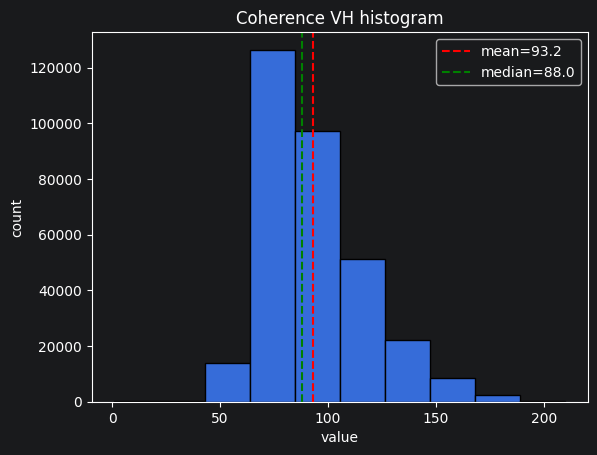

range: 1.0–210.0, mean: 93.17364934072293, median: 88.0, std: 24.517877893588036


In [10]:
import matplotlib.pyplot as plt
cog_path = sentinel_1_cogs[0]
statistics_url = (cog_endpoint / "statistics").with_query(url=cog_path)
print(f"Statistics are retrieved from: {statistics_url}")
response = requests.get(str(statistics_url))
if response.ok:
    data = response.json()["b1"]
    counts, edges = data["histogram"]
    plt.bar(edges[:-1], counts, width=[e2-e1 for e1,e2 in zip(edges, edges[1:])], align="edge", edgecolor="black")
    plt.axvline(data["mean"], color="red", linestyle="--", label=f"mean={data['mean']:.1f}")
    plt.axvline(data["median"], color="green", linestyle="--", label=f"median={data['median']:.1f}")
    plt.title("Coherence VH histogram")
    plt.xlabel("value")
    plt.ylabel("count")
    plt.legend()
    plt.show()

print(f"range: {data['min']}–{data['max']}, mean: {data['mean']}, median: {data['median']}, std: {data['std']}")

Now that we know the COG can be visualised and have some statistics about it, we can request a preview image of the COG. The preview endpoint returns a downsampled version of the COG, which can be used to quickly visualise the COG without loading the entire dataset. The preview endpoint also supports a colormap parameter, which can be used to apply a colormap to the preview image, in this case viridis.

Preview image is retrieved from: https://titiler.terrascope.be/cog/preview?url=/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2026/02/15/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120_VH.tif&colormap_name=viridis


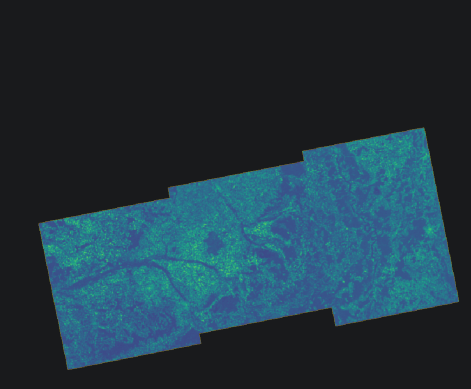

In [11]:
from PIL import Image
from io import BytesIO

preview_url = (cog_endpoint / "preview").with_query(url=cog_path, colormap_name="viridis")
print(f"Preview image is retrieved from: {preview_url}")
response = requests.get(str(preview_url))
if response.ok:
    response = requests.get(str(preview_url))
    img = Image.open(BytesIO(response.content))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Failed to retrieve preview image")

Finally, we can visualize the COG in JupyterGIS using the TiTiler COG endpoint. The cog endpoint can use a XYZ tile URL, which can be used to add the COG as a raster layer in JupyterGIS.

In [12]:
doc = GISDocument(latitude=50.5, longitude=4.5, zoom=7)
doc.add_raster_layer(
    url="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    name="OpenStreetMap"
)

'd62a8e26-8dc8-4a69-a2e1-0656eb8a514b'

In [13]:
def get_tile_endpoint(path):
    return str(cog_endpoint / "tiles" / "WebMercatorQuad") + "/{z}/{x}/{y}" + f"?url={path}&colormap_name=viridis"

print(f"Tile endpoint: {get_tile_endpoint(cog_path)}")
doc.add_raster_layer(
    url=get_tile_endpoint(cog_path),
    name="Coherence VH"
)
doc

Tile endpoint: https://titiler.terrascope.be/cog/tiles/WebMercatorQuad/{z}/{x}/{y}?url=/data/MTDA/TERRASCOPE_Sentinel1/SLC_COHERENCE/2026/02/15/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120/S1C_S1A_Coherence_20260209T173117_20260215T173226_ASC_161_V120_VH.tif&colormap_name=viridis


We can also render multiple COGs this way, by adding them all individually. Lets do this for an entire day.

In [16]:
for i, path in enumerate(sentinel_1_cogs):
    doc.add_raster_layer(
    url=get_tile_endpoint(path),
    name=f"Coherence VH {i}"
)
doc

## 5. More JupyterGIS features

The focus of this notebook was mostly about TiTiler functionality but it has only scratched the surface of what JupyterGIS can do. Here are some features worth exploring in the UI:

### Supported file formats
JupyterGIS can open and display many common geospatial formats:

| Format | Type | Notes |
|---|---|---|
| GeoJSON | Vector | Points, lines, polygons: load local files or remote URLs |
| GeoTIFF / COG | Raster | Local files or streamed from object storage |
| Shapefile, GeoPackage | Vector | Traditional GIS formats |
| WMS / WMTS | Raster service | OGC map and tile services (exactly what we used above) |
| XYZ tiles | Raster service | OpenStreetMap-style slippy map tiles |
| `.jGIS` | Project file | JupyterGIS's own format — saves all layers, styles, and camera position for later |

### Story maps
**Story maps** let you turn a JupyterGIS map into a guided, step-by-step narrative, think of it as a presentation embedded in the map. Each story point captures:

- A specific **camera position** (centre coordinates + zoom level)
- Which **layers are visible** at that step
- A **text annotation** explaining what the viewer should focus on

# 6. Closing remarks
In this notebook, we have explored the functionalities that TiTiler has to offer, using JupyterGIS as an interactive viewer. We used the TiTiler WMTS endpoint to discover renderable layers, and then visualised them in JupyterGIS. We also used the TiTiler COG endpoint to retrieve statistics about a COG and visualise it, without using any STAC metadata.

Most of the endpoints we used in this notebook, you can also visualize easily in QGIS from anywhere. This makes them very useful for sharing and visualising Terrascope data with colleagues, without having to download the data first. Both TiTiler and JupyterGIS have a lot more to offer then we have shown in this notebook, so we encourage you to explore their documentation and try out more features on your own.